In [1]:
import torch
import kagglehub
import pandas as pd
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence ,pack_padded_sequence, pad_packed_sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import compute_class_weight

#nltk
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

import os
import string
from time import time

import matplotlib.pyplot as plt
import seaborn as sns

e:\programming\pytorch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [3]:
ASSET_PATH = r"../asset/7_news/"

In [4]:
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

In [ ]:
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')
nltk.download('punkt')

In [ ]:

# Download latest version
path = kagglehub.dataset_download("rmisra/news-category-dataset")

print("Path to dataset files:", path)

In [7]:
df = pd.read_json(path + "/News_Category_Dataset_v3.json", lines=True)
# df = df.sample(6000, random_state=SEED).reset_index(drop=True)
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  str           
 1   headline           209527 non-null  str           
 2   category           209527 non-null  str           
 3   short_description  209527 non-null  str           
 4   authors            209527 non-null  str           
 5   date               209527 non-null  datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 9.6 MB


In [9]:
df['category'].value_counts()

category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

In [10]:
category_mapping = {
    # Politics / News
    "POLITICS": "politics",
    "WORLD NEWS": "politics",
    "THE WORLDPOST": "politics",
    "WORLDPOST": "politics",
    "U.S. NEWS": "politics",

    # Business / Tech
    "BUSINESS": "business_tech",
    "MONEY": "business_tech",
    "TECH": "business_tech",

    # Lifestyle
    "TRAVEL": "lifestyle",
    "STYLE & BEAUTY": "lifestyle",
    "STYLE": "lifestyle",
    "HOME & LIVING": "lifestyle",
    "WEDDINGS": "lifestyle",
    "FOOD & DRINK": "lifestyle",
    "TASTE": "lifestyle",
    "PARENTING": "lifestyle",
    "PARENTS": "lifestyle",

    # Health
    "WELLNESS": "health",
    "HEALTHY LIVING": "health",

    # Entertainment & Culture
    "ENTERTAINMENT": "entertainment",
    "COMEDY": "entertainment",
    "ARTS": "entertainment",
    "ARTS & CULTURE": "entertainment",
    "CULTURE & ARTS": "entertainment",

    # Society
    "WOMEN": "society",
    "BLACK VOICES": "society",
    "LATINO VOICES": "society",
    "QUEER VOICES": "society",
    "RELIGION": "society",
    "COLLEGE": "society",
    "EDUCATION": "society",
    "DIVORCE": "society",

    # Science & Environment
    "SCIENCE": "science_environment",
    "GREEN": "science_environment",
    "ENVIRONMENT": "science_environment",

    # Sports
    "SPORTS": "sports",

    # Crime
    "CRIME": "crime",

    # Media
    "MEDIA": "media",

    # Misc
    "WEIRD NEWS": "misc",
    "GOOD NEWS": "misc",
    "IMPACT": "misc",
    "FIFTY": "misc",
}
df["category"] = df["category"].map(category_mapping)

In [11]:
df["category"].value_counts()

category
lifestyle              51123
politics               46521
entertainment          26684
health                 24639
society                23793
business_tech           9852
misc                    9060
science_environment     6272
sports                  5077
crime                   3562
media                   2944
Name: count, dtype: int64

In [12]:
df['label'] = df['category'].factorize()[0]

In [13]:
label_mapping = dict(zip(df['category'].unique(), df['label'].unique()))
pd.DataFrame(label_mapping.items(), columns=['category', 'label'])

,category,label
0,politics,0
1,entertainment,1
2,lifestyle,2
3,business_tech,3
4,sports,4
5,misc,5
6,science_environment,6
7,society,7
8,crime,8
9,health,9


In [14]:
df['text'] = df['headline'] + " " + df['short_description']

In [15]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_map = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'N': wordnet.NOUN, 'R': wordnet.ADV}
    return tag_map.get(tag, wordnet.NOUN)

In [16]:

def preprocess_text(text:str):
    #remove punctuation , lowercassing, stopword removals
    stop_words = set(stopwords.words('english'))
    text = text.lower()
    text = ' '.join([word for word in text.split() if word.lower() not in stop_words])
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = ' '.join([lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in text.split()])
    if text.strip() == "":
        return ["<PAD>"]
    return text.split()



In [17]:
tokenized_corpus = [preprocess_text(sentence) for sentence in df['text']]
if not os.path.exists(ASSET_PATH+"vocabs.pth"):
    vocab = {
        "<PAD>":0,
        "<UNK>":1
    }
    for review in tokenized_corpus:
        for word in review:
            if word not in vocab:
                vocab[word] = vocab.__len__()
    vocab_size = vocab.__len__()
    torch.save(vocab, ASSET_PATH+"vocabs.pth")
vocab = torch.load(ASSET_PATH+"vocabs.pth")

In [18]:
def encoder_decoder(key:str|int):
    if type(key) is str:
        return vocab[key]
    elif type(key) is int:
        return list(vocab.keys())[key]
    else:
        raise TypeError("please enter either a string or an integer")

In [19]:
MAX_LEN = 100
tensor_text = [torch.tensor([encoder_decoder(word) for word in review[:MAX_LEN]]) for review in tokenized_corpus]
padded_text = pad_sequence(tensor_text, batch_first=True, padding_value=vocab["<PAD>"])
labels = torch.tensor(df['label'].values)

In [20]:
#You can set STRATIFY to y to maintain the same distribution of classes in train and test sets


x_train, x_test, y_train, y_test = train_test_split(padded_text, labels, test_size=0.2, random_state=SEED)
y_train_np = y_train.numpy()
train_ds = TensorDataset(x_train, y_train)
test_ds = TensorDataset(x_test, y_test)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=32)


In [21]:
class NewsCategorizer(torch.nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(NewsCategorizer,self).__init__()
        self.embedding = torch.nn.Embedding(vocab_size, embed_dim,padding_idx=vocab["<PAD>"])
        self.lstm = torch.nn.LSTM(embed_dim, hidden_size=128, batch_first=True)
        self.fc = torch.nn.Linear(128, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        lengths = (x != vocab["<PAD>"]).sum(dim=1).cpu().clamp(min=1)
        packed_embedded = pack_padded_sequence(embedded, lengths=lengths, batch_first=True, enforce_sorted=False)

        output, (hidden, _) = self.lstm(packed_embedded)
        output = self.fc(hidden[-1])
        return output

In [22]:
model = NewsCategorizer(vocab.__len__(),32,11)
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

# Move model to the device
model.to(device)

NewsCategorizer(
  (embedding): Embedding(107791, 32, padding_idx=0)
  (lstm): LSTM(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=11, bias=True)
)

In [23]:


epochs = 10
for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0
    start_time = time()
    for X_batch, y_batch in train_dl:
        # Move batch to the device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_acc = correct / total
    end_time = time()
    print(f"Epoch {epoch+1} completed. Total Loss: {total_loss:.4f}, Accuracy: {train_acc:.4f}, Time: {end_time - start_time:.4f}s")

Epoch 1 completed. Total Loss: 6250.8426, Accuracy: 0.6204, Time: 126.6213s
Epoch 2 completed. Total Loss: 4755.5515, Accuracy: 0.7117, Time: 121.4208s
Epoch 3 completed. Total Loss: 4259.0104, Accuracy: 0.7402, Time: 1004.9429s
Epoch 4 completed. Total Loss: 3936.2527, Accuracy: 0.7604, Time: 118.0742s
Epoch 5 completed. Total Loss: 3706.8047, Accuracy: 0.7739, Time: 120.7402s
Epoch 6 completed. Total Loss: 3527.5295, Accuracy: 0.7846, Time: 145.4242s
Epoch 7 completed. Total Loss: 3393.8520, Accuracy: 0.7925, Time: 151.9392s
Epoch 8 completed. Total Loss: 3282.0961, Accuracy: 0.8001, Time: 190.2296s
Epoch 9 completed. Total Loss: 3205.7663, Accuracy: 0.8041, Time: 166.6822s
Epoch 10 completed. Total Loss: 3139.2773, Accuracy: 0.8085, Time: 136.7576s


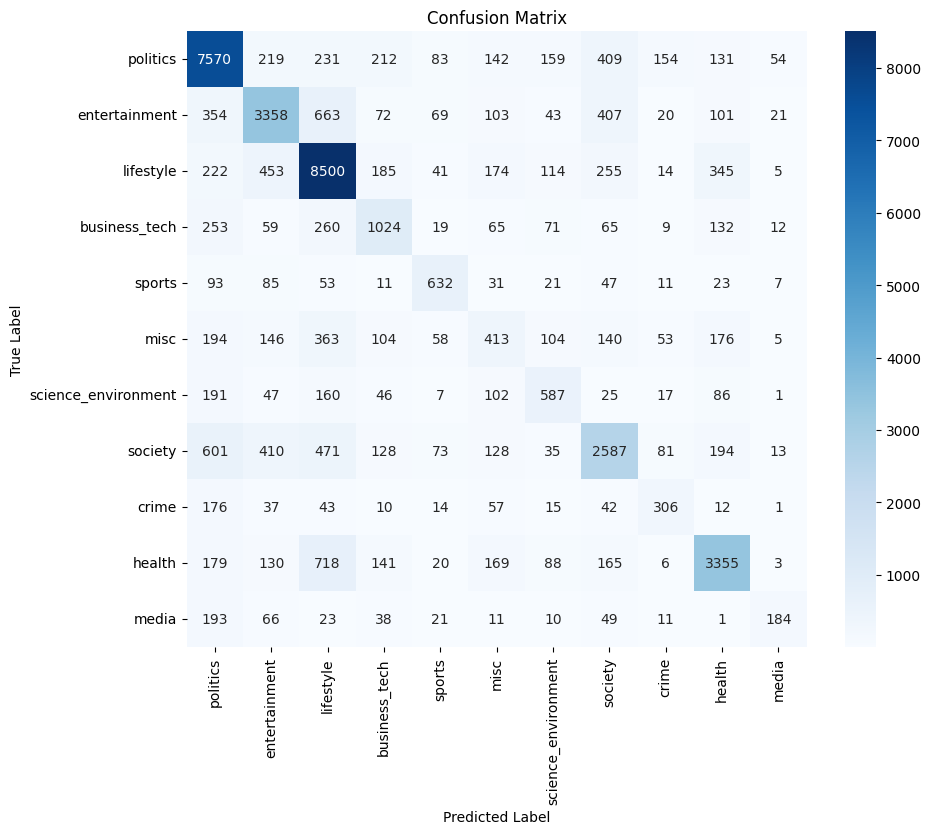

In [24]:
# Import plotting libraries


# Initialize lists to store predictions and true labels
y_pred = []
y_true = []

# Set model to evaluation mode and make predictions
model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_dl:
        # Move batch to the device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(y_batch.cpu().numpy())

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)
# Get target names for the classification report and confusion matrix labels
target_names = sorted(label_mapping, key=label_mapping.get)

# Display the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [25]:
# Calculate and display the classification report
report = classification_report(y_true, y_pred, target_names=target_names)
print("\nClassification Report:")
print(report)


Classification Report:
                     precision    recall  f1-score   support

           politics       0.76      0.81      0.78      9364
      entertainment       0.67      0.64      0.66      5211
          lifestyle       0.74      0.82      0.78     10308
      business_tech       0.52      0.52      0.52      1969
             sports       0.61      0.62      0.62      1014
               misc       0.30      0.24      0.26      1756
science_environment       0.47      0.46      0.47      1269
            society       0.62      0.55      0.58      4721
              crime       0.45      0.43      0.44       713
             health       0.74      0.67      0.70      4974
              media       0.60      0.30      0.40       607

           accuracy                           0.68     41906
          macro avg       0.59      0.55      0.56     41906
       weighted avg       0.67      0.68      0.67     41906



In [27]:
torch.save(model.state_dict(), ASSET_PATH+"News.pth")